In [ ]:
######################
#### Requirements ####
######################

## WILDS Dataset Library Installation ##
# Uncomment these if Needed #
# %pip install wilds
# %pip install transformers

## Imports ##
import numpy as np

## Matplotlib Imports ##
import matplotlib.pyplot as plt

## Collections Imports ##
from collections import Counter

## WILDS Data Imports ##
from wilds import get_dataset
from wilds.common.data_loaders import get_train_loader, get_eval_loader
import torchvision.transforms as transforms

## PyTorch Imports ##
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Subset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## SciKit Imports ##
from sklearn.metrics import f1_score

## Transformers Import ##
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Installations and Library Imports Completed Succesfully")

Installations and Library Imports Completed Succesfully


In [10]:
##########################
#### Data Downloading ####
##########################

## WILDS Dataset ##
wildsDatasetName = "civilcomments"
wildsDataset = get_dataset(dataset=wildsDatasetName, download=True)

print("WILDS Dataset Loading Completed Succesfully")

WILDS Dataset Loading Completed Succesfully


In [11]:
########################################
#### Data Loading and Configuration ####
########################################

## WILDS Training Data ##
batchSize = 16
wildsTrainingData = wildsDataset.get_subset("train")
wildsTrainingData_Tiny = wildsDataset.get_subset("train", frac=0.1)
wildsTrainingData_Small = wildsDataset.get_subset("train", frac=0.2)
wildsTrainingData_Medium = wildsDataset.get_subset("train", frac=0.5)
wildsTrainingDataLoader_Tiny = get_train_loader("standard", wildsTrainingData_Tiny, batch_size=batchSize)
wildsTrainingDataLoader_Small = get_train_loader("standard", wildsTrainingData_Small, batch_size=batchSize)
wildsTrainingDataLoader_Medium = get_train_loader("standard", wildsTrainingData_Medium, batch_size=batchSize)
wildsTrainingDataLoader = get_train_loader("standard", wildsTrainingData, batch_size=batchSize)

## WILDS Testing Data ##
batchSize = 16
wildsTestingData = wildsDataset.get_subset("test")
wildsTestingDataLoader = get_eval_loader("standard", wildsTestingData, batch_size=batchSize)

print("WILDS Training and Testing Data Loaders Configuration Completed Succesfully")

WILDS Training and Testing Data Loaders Configuration Completed Succesfully


In [ ]:
####################################################
#### Experiment 7 | Data Availability Viewpoint ####
####################################################

## Experiment 7 - Test Data Constraints Effect on Model Performance with Checkpoints on Data Size ##

## Track Metrics ##
exp2AccuracyScores = []
exp2F1Scores = []

## Testing Portion Function ##
def evaluate(model, loader):
    model.eval()
    predictions = []
    labels = []

    with torch.no_grad():
        for x, y, _ in loader:
            inputs = tokenizer(list(x), padding=True, truncation=True, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            p = outputs.logits.argmax(dim=1)
            predictions.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    acc = np.mean(np.array(predictions) == np.array(labels))
    f1 = f1_score(labels, predictions)
    return acc, f1


## Training Portion ##
dataLoaders = [
    ("Tiny", wildsTrainingDataLoader_Tiny),
    ("Small", wildsTrainingDataLoader_Small),
    ("Medium", wildsTrainingDataLoader_Medium)
]
for name, loader in dataLoaders:

    ## Define the Model ##
    labels = []
    for _, y, _ in loader:
        labels.extend(y.numpy())
    counts = Counter(labels)
    total = sum(counts.values())
    classWeights = torch.tensor([total / counts[0], total / counts[1]], dtype=torch.float).to(device)
    model = AutoModelForSequenceClassification.from_pretrained(modelName, num_labels=2).to(device)
    optimizer = Adam(model.parameters(), lr=2e-5)

    ## Train the Model in Specific Data Subset ##
    for epoch in range(10):
        model.train()
        for index, (x, y, _) in enumerate(loader):
            inputs = tokenizer(list(x), padding=True, truncation=True, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            y = y.to(device)
            outputs = model(**inputs)
            loss = lossFunction(outputs.logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if (index % 100 == 0):
                print(f"\rTesting -> Sample: {index}", end="", flush=True)

    ## Test and Report the Metrics ##
    accuracy, f1 = evaluate(model, wildsTestingDataLoader)
    exp2AccuracyScores.append(accuracy)
    exp2F1Scores.append(f1)
    print(f"\n{name} Model | Accuracy: {accuracy:.4f} | F1 Score: {f1:.4f}")

print("Experiment 2 Completed Succesfully")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing -> Sample: 1600
Tiny Model | Accuracy: 0.9071 | F1 Score: 0.5911


/home/hice1/csempf3/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing -> Sample: 3300
Small Model | Accuracy: 0.9145 | F1 Score: 0.5817


/home/hice1/csempf3/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.bias', 'classifier.weight', 'classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing -> Sample: 8400
Medium Model | Accuracy: 0.9176 | F1 Score: 0.6023
Experiment 2 Completed Succesfully


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


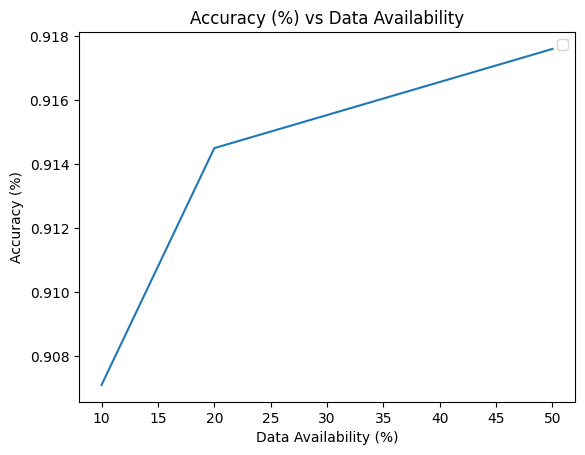

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


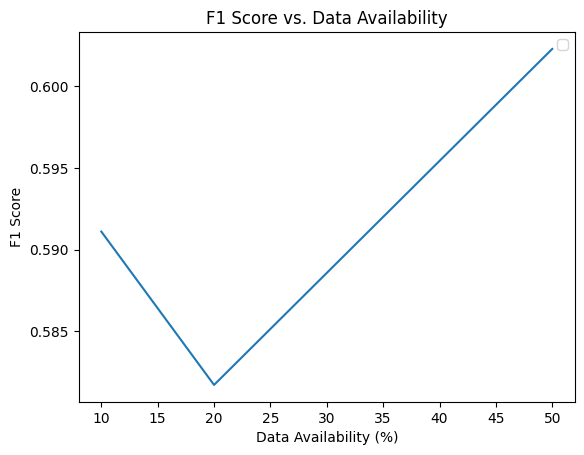

In [7]:
##########################
#### Plotting Metrics ####
##########################

## Data ##
exp2AccuracyScores = [0.9071, 0.9145, 0.9176]
exp2F1Scores = [0.5911, 0.5817, 0.6023]
dataAvailability = [10, 20, 50]

## Plot Accuracy ##
plt.figure()
plt.plot(dataAvailability, exp2AccuracyScores)
plt.xlabel("Data Availability (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy (%) vs Data Availability")
plt.legend()
plt.savefig("../figures/fig7a_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot F1 Score ##
plt.figure()
plt.plot(dataAvailability, exp2F1Scores)
plt.xlabel("Data Availability (%)")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Data Availability")
plt.legend()
plt.savefig("../figures/fig7b_f1.png", dpi=300, bbox_inches="tight")
plt.show()